**Лабораторная работа №1 «Первичное исследование и оценка
качества данных»**

Датасет: coffee analysis - оценки и характеристики кофе

**1. Постановка задачи:**

**Датасет содержит** информацию о более чем 1000 образцах кофе, которые прошли дегустацию. Каждая запись включает название кофе, обжарщика, степень обжарки, страну нахождения обжарщика, страну происхождения зерна, цену за 100 грамм, рейтинг и текстовое описание вкусовых характеристик.

**Условный заказчик:** сеть кофеен или магазин по продаже кофе, которые хотят оптимизировать свой ассортимент; кофейные сомелье.

**Возможные задачи ИАД:**
1) Выявление закономерностей между рейтингом кофе и его характеристиками (цена, страна происхождения, степень обжарки).
2) Группировка кофе по его вкусовым качествам на основе текстовых описаний для создания рекомендаций.
3) Выявление образцов кофе с нетипичным соотношением цены и рейтинга, а также аномально высокими или низкими ценами.

**2. Паспорт датасета:**

In [1]:
#подключаем необходимые бибилиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#подключаемся к Google Drive, чтобы не перезагружать файл каждый раз
from google.colab import drive

drive.mount('/content/drive/')
df=pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/coffee_analysis.csv')

print(f'Файл загружен. Размер датасета: {df.shape[0]} строк; {df.shape[1]} столбцов')
df.head()

passport=pd.DataFrame({
    'Признак:': df.columns,
    'Тип pandas:': df.dtypes.astype(str).values,
    'Количество уникальных значений:': [df[c].nunique(dropna=True) for c in df.columns],
})

#выводим датасет
print("Паспорт датасета:")
passport

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Файл загружен. Размер датасета: 2095 строк; 12 столбцов
Паспорт датасета:


,Признак:,Тип pandas:,Количество уникальных значений:
0,name,object,1909
1,roaster,object,424
2,roast,object,5
3,loc_country,object,19
4,origin_1,object,614
5,origin_2,object,357
6,100g_USD,float64,473
7,rating,int64,15
8,review_date,object,61
9,desc_1,object,2092


Переведём признаки, чтобы их было проще понять

|Признак|Перевод|
|---|---|
|`name`|Сорт кофе|
|`roaster`|Компания-обжарщик|
|`roast`|Степень обжарки|
|`loc_country`|Страна, где находится обжарщик|
|`origin_1`|Основной регион происхождения зерна|
|`origin_2`|Дополнительный регион происхождения зерна|
|`100g_USD`|Цена за 100 грамм в долларах США|
|`rating`|Рейтинг кофе (от 0 до 100)|
|`review_date`|Дата публикации обзора|
|`desc_1` |Основное описание вкусовых характеристик|
|`desc_2` |Дополнительная информация от обжарщика|
|`desc_3` |Краткое резюме от обжарщика|

In [2]:
#переведем дату публикации в формат даты, а не строки

df['review_date']=pd.to_datetime(df['review_date'], format='%B %Y', errors='coerce')

print(df.dtypes)
print('Некорректных дат:', df['review_date'].isna().sum())

name                   object
roaster                object
roast                  object
loc_country            object
origin_1               object
origin_2               object
100g_USD              float64
rating                  int64
review_date    datetime64[ns]
desc_1                 object
desc_2                 object
desc_3                 object
dtype: object
Некорректных дат: 0


**3. Аудит качества данных:**

3.1 Проверим наличие пропусков:

In [3]:
missing_values=pd.DataFrame({
    'Количество пропусков:': df.isna().sum(),
    'Доля пропусков, %:': (df.isna().mean()*100).round(2)
}).sort_values(by='Количество пропусков:', ascending=False)

print("Информация о пропусках:")
missing_values

Информация о пропусках:


,Количество пропусков:,"Доля пропусков, %:"
roast,15,0.72
desc_3,2,0.10
roaster,0,0.00
name,0,0.00
loc_country,0,0.00
origin_1,0,0.00
100g_USD,0,0.00
origin_2,0,0.00
rating,0,0.00
review_date,0,0.00


Вывод: по результатам проверки в датасете обнаружены пропуски только в двух признаках:

1) roast - 15 пропусков (0.72 %). Это категориальный признак, обозначающий степень обжарки кофе. Пропуски в этом столбце могут быть критичны для анализа, так как степень обжарки является одним из ключевых факторов, влияющих на вкусовые рекомендации и рейтинг кофе.

2) desc_3 - 2 пропуска (0.10%). Это текстовое поле с кратким резюме от обжарщика. Пропуски здесь не критичны, так как их всего 2, и этот признак не используется в стандартном числовом или категориальном анализе.

Остальные 10 признаков пропусков не имеют, что говорит о высоком качестве собранных данных.

3.2 Проверим наличие дубликатов:

In [4]:
duplicates=df.duplicated().sum()
print(f'Количество полных дубликатов: {duplicates}')

#также проверим дубликаты по названию кофе, поскольку кофе с одним названием может быть обжарен в разных странах
if 'name' in df.columns:
    name_duplicates=df['name'].duplicated().sum()
    print(f'Количество дубликатов по названию кофе (name): {name_duplicates}')

Количество полных дубликатов: 0
Количество дубликатов по названию кофе (name): 186


Вывод: в ходе проверки были получены следующие результаты:

1) Полных дубликатов: 0. Это говорит о том, что данные не были случайно продублированы при загрузке или сборе.

2) Дубликатов по названию кофе: 186. Это не является ошибкой. Один и тот же сорт кофе может встречаться в датасете несколько раз по нескольким причинам: разные обжарщики. разные годы, разные партии и разные степени обжарки.

3.4 Проверим типические проблемы значений:

In [5]:
numeric_signs=df.select_dtypes(include=['int64', 'float64']).columns
print(f"Числовые признаки: {list(numeric_signs)}")

numeric_values=df[numeric_signs].describe().T
numeric_values['median']=df[numeric_signs].median()
numeric_values=numeric_values[['min', 'max', 'mean', 'std', 'median']]
numeric_values=numeric_values.round(2)

print("Основные значения по числовым признакам:")
print(numeric_values)


print("Проверка на подозрительные значения:")

price_error=(df['100g_USD']<=0).sum()
print(f"Цена '100g_USD'<=0: {price_error} строк")

price_high=(df['100g_USD']>100).sum()
print(f"Цена '100g_USD'>100 USD (очень дорого): {price_high} строк")

if price_error>0:
    print("Строки с некорректной ценой:")
    df[df['100g_USD'] <= 0][['name', 'roaster', '100g_USD']]

rating_error=((df['rating']<0)|(df['rating'] > 100)).sum()
print(f"Рейтинг 'rating' вне диапазона [0, 100]: {rating_error} строк")

if price_high>0:
    print("Примеры самого дорогого кофе:")
    display(df.nlargest(10, '100g_USD')[['name', 'roaster', '100g_USD', 'rating']])

Числовые признаки: ['100g_USD', 'rating']
Основные значения по числовым признакам:
            min     max   mean    std  median
100g_USD   0.12  132.28   9.32  11.43    5.86
rating    84.00   98.00  93.11   1.56   93.00
Проверка на подозрительные значения:
Цена '100g_USD'<=0: 0 строк
Цена '100g_USD'>100 USD (очень дорого): 8 строк
Рейтинг 'rating' вне диапазона [0, 100]: 0 строк
Примеры самого дорогого кофе:


,name,roaster,100g_USD,rating
1577,Mama Cata Mokkita,Paradise Roasters,132.28,97
1578,Ethiopia Tamiru Tadesse Anaerobic,Genesis Coffee Lab,127.87,96
1785,Ecuador Taza Dorada Finca Cruz Loma,Paradise Roasters,123.46,96
1755,Ecuador Finca Cruz Loma,Simon Hsieh Aroma Roast Coffees,115.20,95
235,Esmeralda Estate Panama Geisha,Difference Coffee,111.11,94
811,Esmeralda Estate Panama Geisha,Difference Coffee,111.11,94
1374,Esmeralda Estate Panama Geisha,Difference Coffee,111.11,94
1897,Esmeralda Estate Panama Geisha,Difference Coffee,111.11,94
1004,Esmeralda Estate Panama Geisha,Difference Coffee,100.00,94
74,Civet Yirgacheffe Sisota,"Good Chance Biotechnology, Ltd.",90.83,93


In [6]:
cat_signs=df.select_dtypes(include=['object', 'category']).columns

#исключим длинные текстовые описания из анализа
text_cols=['desc_1', 'desc_2', 'desc_3']
cat_signs_short=[c for c in cat_signs if c not in text_cols]

print(f"Категориальные признаки для анализа: {cat_signs_short}")

print("Количество уникальных значений:")
for col in cat_signs_short:
    n_unique=df[col].nunique()
    print(f"{col}: {n_unique} уникальных значений")

print("Проверка на 'грязные' категории:")

for col in cat_signs_short:
    values=df[col].dropna().astype(str)

    leading_spaces=values.str.startswith(' ').sum()
    trailing_spaces = values.str.endswith(' ').sum()
    double_spaces=values.str.contains('  ').sum()

    values_lower=values.str.lower()
    n_unique_case_sensitive=values.nunique()
    n_unique_case_insensitive=values_lower.nunique()
    case_issues=n_unique_case_sensitive - n_unique_case_insensitive

    print(f"{col}:")
    print(f"Уникальных (с учётом регистра): {n_unique_case_sensitive}")
    print(f"Уникальных (без учёта регистра): {n_unique_case_insensitive}")
    print(f"Проблемы с регистром: {case_issues}")
    print(f"Пробелы в начале: {leading_spaces}")
    print(f"Пробелы в конце: {trailing_spaces}")
    print(f"Двойные пробелы: {double_spaces}")

Категориальные признаки для анализа: ['name', 'roaster', 'roast', 'loc_country', 'origin_1', 'origin_2']
Количество уникальных значений:
name: 1909 уникальных значений
roaster: 424 уникальных значений
roast: 5 уникальных значений
loc_country: 19 уникальных значений
origin_1: 614 уникальных значений
origin_2: 357 уникальных значений
Проверка на 'грязные' категории:
name:
Уникальных (с учётом регистра): 1909
Уникальных (без учёта регистра): 1909
Проблемы с регистром: 0
Пробелы в начале: 0
Пробелы в конце: 0
Двойные пробелы: 0
roaster:
Уникальных (с учётом регистра): 424
Уникальных (без учёта регистра): 420
Проблемы с регистром: 4
Пробелы в начале: 0
Пробелы в конце: 2
Двойные пробелы: 0
roast:
Уникальных (с учётом регистра): 5
Уникальных (без учёта регистра): 5
Проблемы с регистром: 0
Пробелы в начале: 0
Пробелы в конце: 0
Двойные пробелы: 0
loc_country:
Уникальных (с учётом регистра): 19
Уникальных (без учёта регистра): 19
Проблемы с регистром: 0
Пробелы в начале: 0
Пробелы в конце: 0
Д

In [7]:
#почистим категориальные признаки
#убираем пробелы
df['roaster']=df['roaster'].str.strip()

#выбираем самый частый вариант написания при различии в регистре
roaster_lower=df['roaster'].str.lower()

canonical_names={}
for lower_name, group in df.groupby(roaster_lower)['roaster']:
    if len(group.unique())>1:
        most_common=group.value_counts().idxmax()
        canonical_names[lower_name]=most_common
        print(f"Нормализация: {list(group.unique())} - '{most_common}'")

df['roaster'] = roaster_lower.map(canonical_names).fillna(df['roaster'])

print("После очистки:")
print(f"Уникальных значений в 'roaster': {df['roaster'].nunique()}")

Нормализация: ['Beanfruit Coffee Co.', 'BeanFruit Coffee Co.'] - 'BeanFruit Coffee Co.'
Нормализация: ['Coffee By Design', 'Coffee by Design'] - 'Coffee By Design'
Нормализация: ['RamsHead Coffee Roasters', 'Ramshead Coffee Roasters'] - 'RamsHead Coffee Roasters'
Нормализация: ['Roadmap CoffeeWorks', 'Roadmap Coffeeworks'] - 'Roadmap CoffeeWorks'
После очистки:
Уникальных значений в 'roaster': 418


3.4 Проверим выбросы:

Выбросы по цене:
Границы: [-6.64, 20.35]
Найдено выбросов: 175
Выбросы по рейтингу:
Границы: [86.00, 100.00]
Найдено выбросов: 3


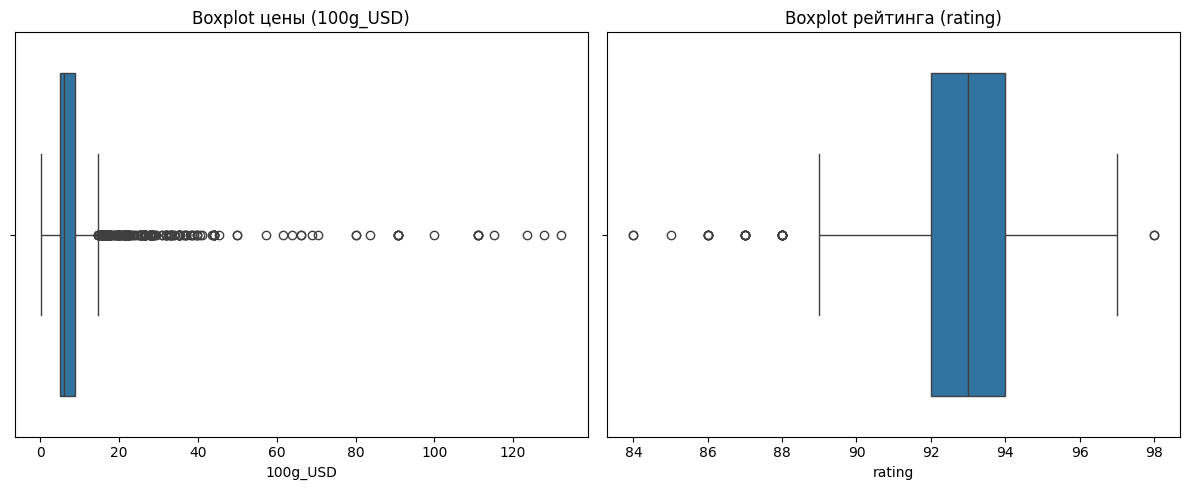

In [8]:
def find_outliers_iqr(series):
    Q1=series.quantile(0.25)
    Q3=series.quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-3*IQR
    upper_bound=Q3+3*IQR
    outliers=series[(series < lower_bound)|(series > upper_bound)]
    return outliers, lower_bound, upper_bound

#анализ выбросов для цены
price_outliers, price_lower, price_upper=find_outliers_iqr(df['100g_USD'])
print(f"Выбросы по цене:")
print(f"Границы: [{price_lower:.2f}, {price_upper:.2f}]")
print(f"Найдено выбросов: {len(price_outliers)}")

#анализ выбросов для рейтинга
rating_outliers, rating_lower, rating_upper = find_outliers_iqr(df['rating'])
print(f"Выбросы по рейтингу:")
print(f"Границы: [{rating_lower:.2f}, {rating_upper:.2f}]")
print(f"Найдено выбросов: {len(rating_outliers)}")

#визуализация выбросов
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['100g_USD'])
plt.title('Boxplot цены (100g_USD)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['rating'])
plt.title('Boxplot рейтинга (rating)')
plt.tight_layout()
plt.show()

Вывод:

Выбросы по цене:
Границы IQR: **[-6.64; 20.35]**

Найдено выбросов: **175**

Метод IQR с коэффициентом 3.0 помечает как выбросы всё, что дороже 20.35 USD. Это не ошибки, а премиум-сегмент рынка кофе.

Выбросы по рейтингу:

Границы IQR: **[86.00; 100.00]**

Найдено выбросов: **3**

Практически все рейтинги попадают в диапазон [86; 100], и лишь 3 записи имеют рейтинг ниже 86. Это редкие случаи, но также валидные данные: не каждsq кофе получает оценку выше 86.

Boxplot:

По цене: видно, что основная масса значений сжата в узком диапазоне (1–20 USD), а справа — длинный хвост из точек премиум-сорта.

По рейтингу: основная масса значений внутри ящика (92–95), и всего несколько крайних точек.

**4. Разведочный анализ:**

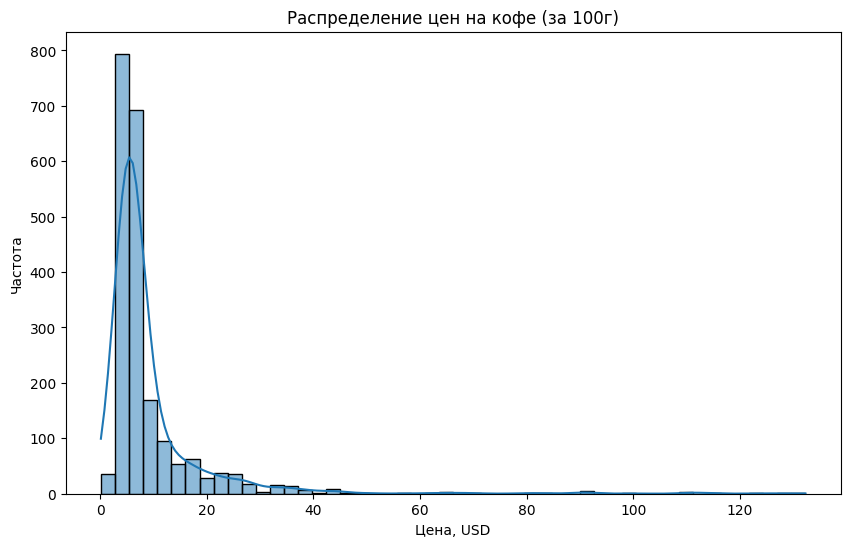

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['100g_USD'], bins=50, kde=True)
plt.title('Распределение цен на кофе (за 100г)')
plt.xlabel('Цена, USD')
plt.ylabel('Частота')
plt.show()

Вывод: распределение имеет ярко выраженную асимметрию. Большинство сортов кофе стоят до 10-15 долларов за 100 грамм, но есть небольшое количество очень дорогих сортов, которые создают длинный хвост.

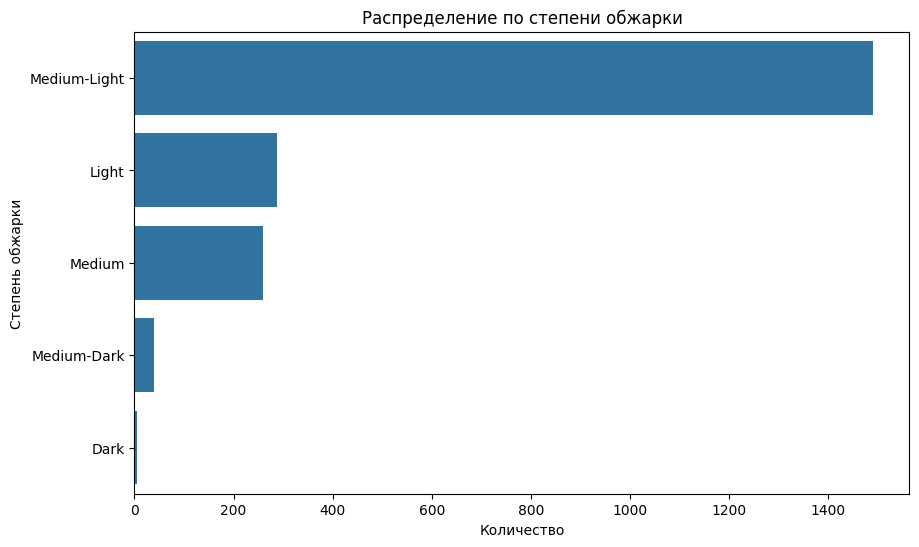

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(y=df['roast'], order=df['roast'].value_counts().index)
plt.title('Распределение по степени обжарки')
plt.xlabel('Количество')
plt.ylabel('Степень обжарки')
plt.show()

Вывод: наиболее часто встречающаяся степень обжарки - 'Medium-Light'. Это говорит о популярности данного стиля среди производителей.

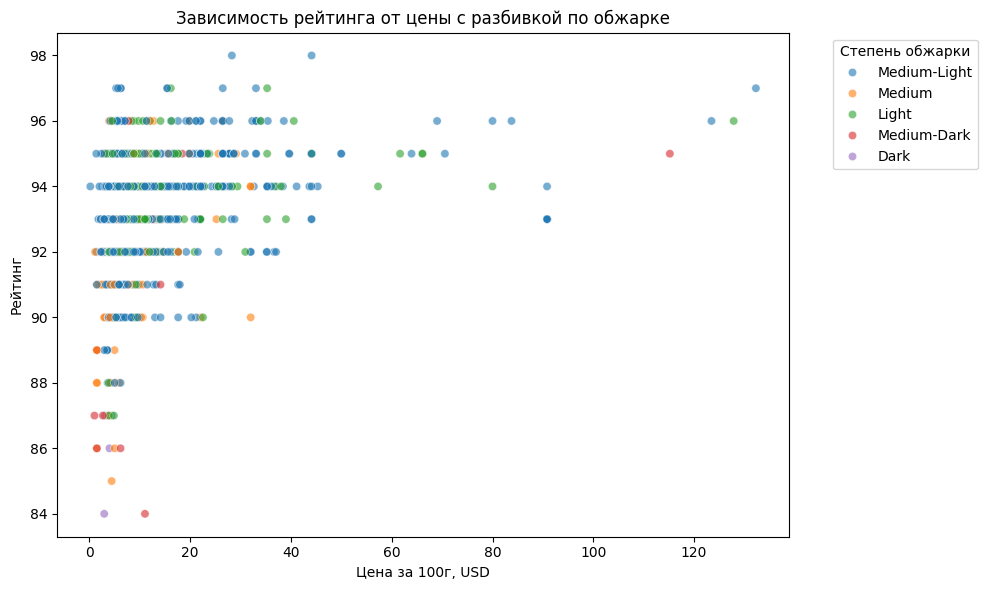

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='100g_USD', y='rating', alpha=0.6, hue='roast')
plt.title('Зависимость рейтинга от цены с разбивкой по обжарке')
plt.xlabel('Цена за 100г, USD')
plt.ylabel('Рейтинг')
plt.legend(title='Степень обжарки', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Вывод: на графике видно, что прямой линейной зависимости между ценой и рейтингом нет. Однако можно заметить, что самые высокие рейтинги (95+) встречаются в широком диапазоне цен. Самые дешевые сорта кофе (<5 USD) имеют рейтинг в основном ниже 93. Также можно увидеть, что разные степени обжарки распределены по всему графику, но, например, 'Light' обжарка чаще встречается в более дорогом сегменте.